In [4]:

import pandas as pd
import time


In [3]:
import requests

# 1. Define the endpoint and parameters
url = "https://api.elections.kalshi.com/trade-api/v2/markets"
params = {
    "series_ticker": "KXMAYORNYCPARTY",
    "status": "settled"
}

# 2. Make the request
response = requests.get(url, params=params)

# 3. Check if successful and parse
if response.status_code == 200:
    data = response.json()
    markets = data.get('markets', [])

    # This mimics: jq '.markets[] | {ticker, title}'
    for market in markets:
        print(f"Ticker: {market['ticker']}")
        print(f"Title:  {market['title']}")
        print("-" * 30)
else:
    print(f"Error: {response.status_code}")
    print(response.text)

Ticker: KXMAYORNYCPARTY-25-AC
Title:  Will a representative of the Andrew Cuomo party win the NYC Mayor race in 2025?
------------------------------
Ticker: KXMAYORNYCPARTY-25-JWAL
Title:  Will a representative of the Jim Walden party win the NYC Mayor race in 2025?
------------------------------
Ticker: KXMAYORNYCPARTY-25-EADA
Title:  Will a representative of the Eric Adams party win the NYC Mayor race in 2025?
------------------------------
Ticker: KXMAYORNYCPARTY-25-R
Title:  Will a representative of the Republican party win the NYC Mayor race in 2025?
------------------------------
Ticker: KXMAYORNYCPARTY-25-D
Title:  Will a representative of the Democratic party win the NYC Mayor race in 2025?
------------------------------


In [16]:

def get_total_history(start_ts, end_ts):
    # 1. API Setup
    series = "KXMAYORNYCPARTY"
    market = "KXMAYORNYCPARTY-25-R"
    url = f"https://api.elections.kalshi.com/trade-api/v2/series/{series}/markets/{market}/candlesticks"



    all_points = []
    cursor = None # This is our 'bookmark'

    print("--- Starting Full Data Extraction ---")

    while True:
        # 2. Prepare the request
        params = {
            "start_ts": start_ts,
            "end_ts": end_ts,
            "period_interval": 1440, # Daily data
        }
        if cursor:
            params["cursor"] = cursor

        # 3. Fetch the 'page'
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"Error: {response.text}")
            break

        data = response.json()
        batch = data.get("candlesticks", [])

        # Add this batch to our master list
        all_points.extend(batch)
        print(f"Captured {len(all_points)} data points...")

        # 4. Check if there is another page
        cursor = data.get("cursor")
        if not cursor or not batch:
            print("Reached the end of the data!")
            break

        # Be polite to the API
        time.sleep(0.1)

    # 5. Process into a clean table
    df = pd.json_normalize(all_points)
    df['date'] = pd.to_datetime(df['end_period_ts'], unit='s')


    return df[['date', 'yes_bid.close_dollars', 'yes_bid.high_dollars',  'yes_bid.low_dollars', 'volume', 'open_interest']]

# Range: July 1st, 2025 to Dec 31st, 2025
start_ts = 1730419200
end_ts = 1767225600

# Run it
df_full = get_total_history(start_ts, end_ts)

# Show the results
print("\nFirst 5 days (July):")
print(df_full.head())
print("\nLast 5 days (Election Month):")
print(df_full.tail())


# Save to CSV so you can see every single point in Excel
df_full.to_csv("nyc_mayor_complete_2025.csv", index=False)

--- Starting Full Data Extraction ---
Captured 303 data points...
Reached the end of the data!

First 5 days (July):
                 date yes_bid.close_dollars yes_bid.high_dollars  \
0 2024-11-10 05:00:00                0.1000               0.1000   
1 2024-11-11 05:00:00                0.0900               0.1000   
2 2024-11-12 05:00:00                0.0900               0.0900   
3 2024-11-13 05:00:00                0.1000               0.1000   
4 2024-11-14 05:00:00                0.1000               0.1000   

  yes_bid.low_dollars  volume  open_interest  
0              0.0000     396            396  
1              0.0900       0            396  
2              0.0900       6            402  
3              0.0900     625           1026  
4              0.1000     108           1134  

Last 5 days (Election Month):
                   date yes_bid.close_dollars yes_bid.high_dollars  \
298 2025-11-03 04:00:00                0.0000               0.0000   
299 2025-11-04 05:00:

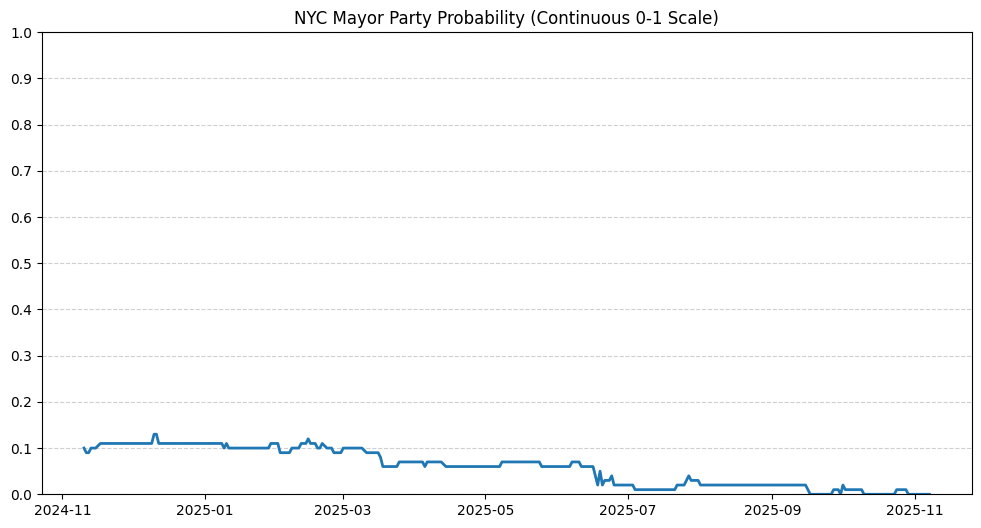

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(df_full['date'], df_full['yes_bid.close_dollars'], linewidth=2)

# 3. SET THE BOUNDS (This makes the axis continuous 0-1)
plt.ylim(0, 1.0)

# 4. SET THE TICKS (This places the numbers)
plt.yticks(np.arange(0, 1.1, 0.1))

# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Probability (Continuous 0-1 Scale)")
plt.show()

In [18]:
#mamdani = df_full
#cuomo = df_full
sliwa = df_full

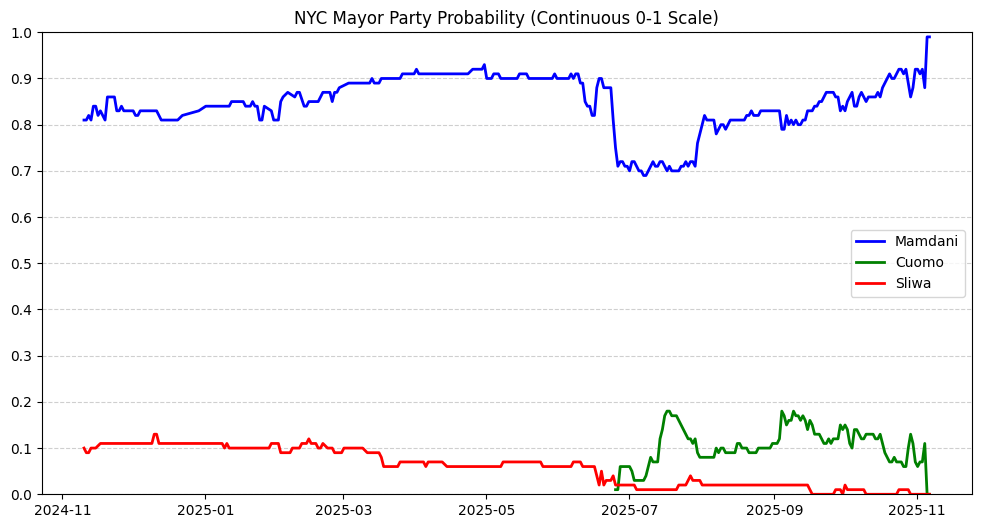

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(mamdani[:-1]['date'], mamdani[:-1]['yes_bid.close_dollars'], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo[:-1]['date'], cuomo[:-1]['yes_bid.close_dollars'], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa[:-1]['date'], sliwa[:-1]['yes_bid.close_dollars'], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()
# 3. SET THE BOUNDS (This makes the axis continuous 0-1)
plt.ylim(0, 1.0)

# 4. SET THE TICKS (This places the numbers)
plt.yticks(np.arange(0, 1.1, 0.1))

# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Probability (Continuous 0-1 Scale)")
plt.show()

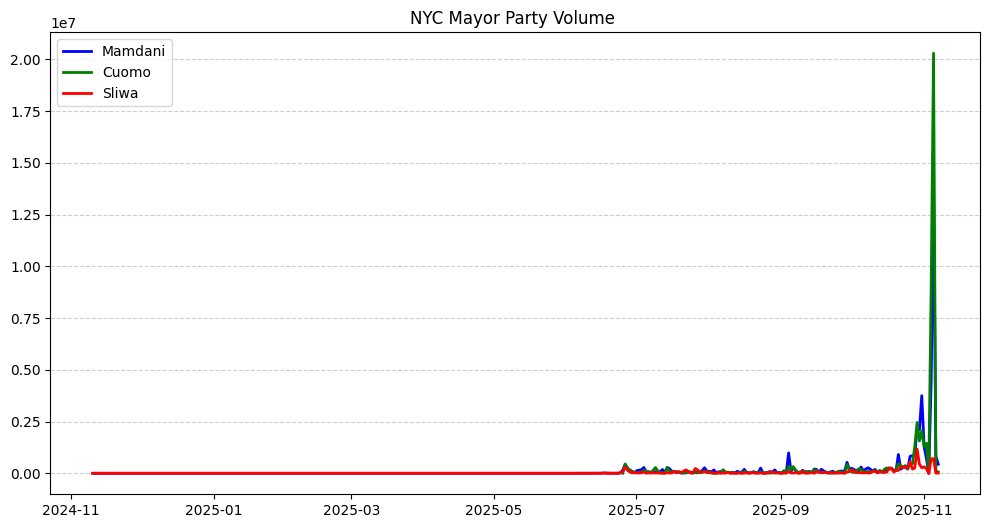

In [21]:

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
df_full['yes_bid.close_dollars'] = pd.to_numeric(df_full['yes_bid.close_dollars'])

plt.figure(figsize=(12, 6))

# 2. Plot the line
plt.plot(mamdani['date'], mamdani['volume'], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo['date'], cuomo['volume'], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa['date'], sliwa['volume'], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()


# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party Volume ")
plt.show()

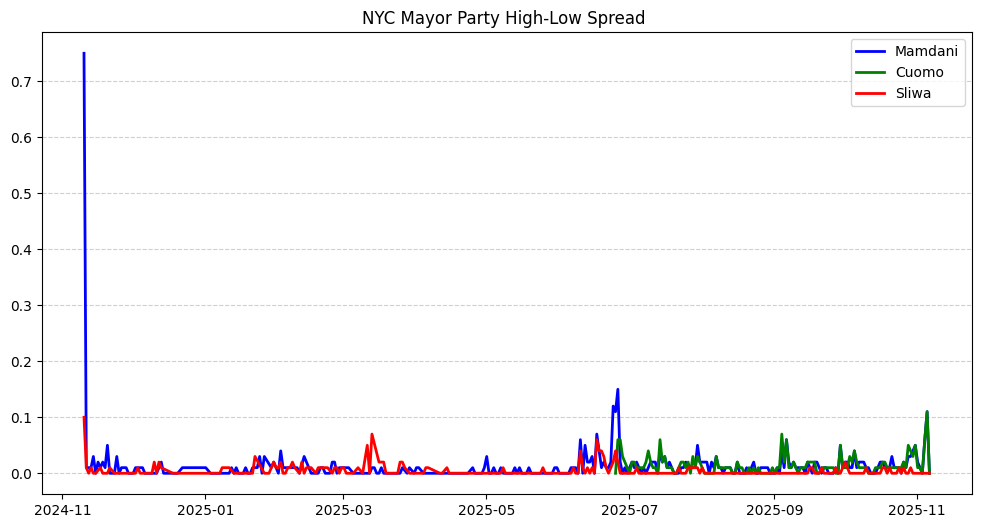

In [25]:

# 1. Ensure data is numeric and sorted (CRITICAL)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full = df_full.sort_values('date')
mamdani['yes_bid.high_dollars'] = pd.to_numeric(mamdani['yes_bid.high_dollars'])
mamdani['yes_bid.low_dollars'] = pd.to_numeric(mamdani['yes_bid.low_dollars'])

cuomo['yes_bid.high_dollars'] = pd.to_numeric(cuomo['yes_bid.high_dollars'])
cuomo['yes_bid.low_dollars'] = pd.to_numeric(cuomo['yes_bid.low_dollars'])

sliwa['yes_bid.high_dollars'] = pd.to_numeric(sliwa['yes_bid.high_dollars'])
sliwa['yes_bid.low_dollars'] = pd.to_numeric(sliwa['yes_bid.low_dollars'])

plt.figure(figsize=(12, 6))

mamdami_spread = mamdani['yes_bid.high_dollars'] - mamdani['yes_bid.low_dollars']
cuomo_spread = cuomo['yes_bid.high_dollars'] - cuomo['yes_bid.low_dollars']
sliwa_spread = sliwa['yes_bid.high_dollars'] - sliwa['yes_bid.low_dollars']

# 2. Plot the xd
plt.plot(mamdani[:-1]['date'], mamdami_spread[:-1], color='blue', label='Mamdani', linewidth=2)
plt.plot(cuomo[:-1]['date'], cuomo_spread[:-1], color='green', label='Cuomo', linewidth=2)
plt.plot(sliwa[:-1]['date'], sliwa_spread[:-1], color='red', label='Sliwa', linewidth=2)

# Optional: Add a legend so people know which color is which
plt.legend()


# 5. Add Grid for better visibility
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.title("NYC Mayor Party High-Low Spread ")
plt.show()